# IntroML2026 Final Project : Predicting Nuclear Waste Temperature

**Group name :** Bétonbraisé

**Authors:** Alice Verniquet and Laura Monney


# 1. Introduction

<div style="text-align: justify;">
This project aims to predict the temperature evolution around nuclear waste canisters 
using measurements from approximately 300 sensors and known heating power values. 
The data spans three different experimental modes, each with distinct heating profiles. 
Our goal is to build a machine learning model that can generalize to unseen sensor 
locations, potentially replacing computationally expensive methods such as finite element simulations.
</div>

# 2. Imports and data loading

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.spatial import KDTree
from typing import Optional, Tuple, List, Dict
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"

#data loading
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)
print(test.columns.tolist())

['sensor', 'time', 'power']


# 3. Data exploration

In [200]:
#displaying the first rows of the dataframes
sensors.head()

,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0


In [201]:
#inspecting the dataframes
print(train.info())
print(sensors.shape)
print(test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Data columns (total 4 columns):
 #   Column       Dtype   
---  ------       -----   
 0   sensor       category
 1   time         float64 
 2   power        float32 
 3   temperature  float32 
dtypes: category(1), float32(2), float64(1)
memory usage: 113.8 MB
None
(325, 4)
(2190480, 3)


In [202]:
#Statistics
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [203]:
#detecting missing values
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [204]:
#finding the number of the two sensors which are very far from our expected values; outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier['sensor'], pos_outlier['sensor'])

483784     N277
483785     N277
483786     N277
483787     N277
483788     N277
           ... 
4910859    N277
4910860    N277
4910861    N277
4910862    N277
4910863    N277
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96'] 2181592    N927
2181593    N927
2181594    N927
2181595    N927
2181596    N927
           ... 
6608667    N927
6608668    N927
6608669    N927
6608670    N927
6608671    N927
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96']


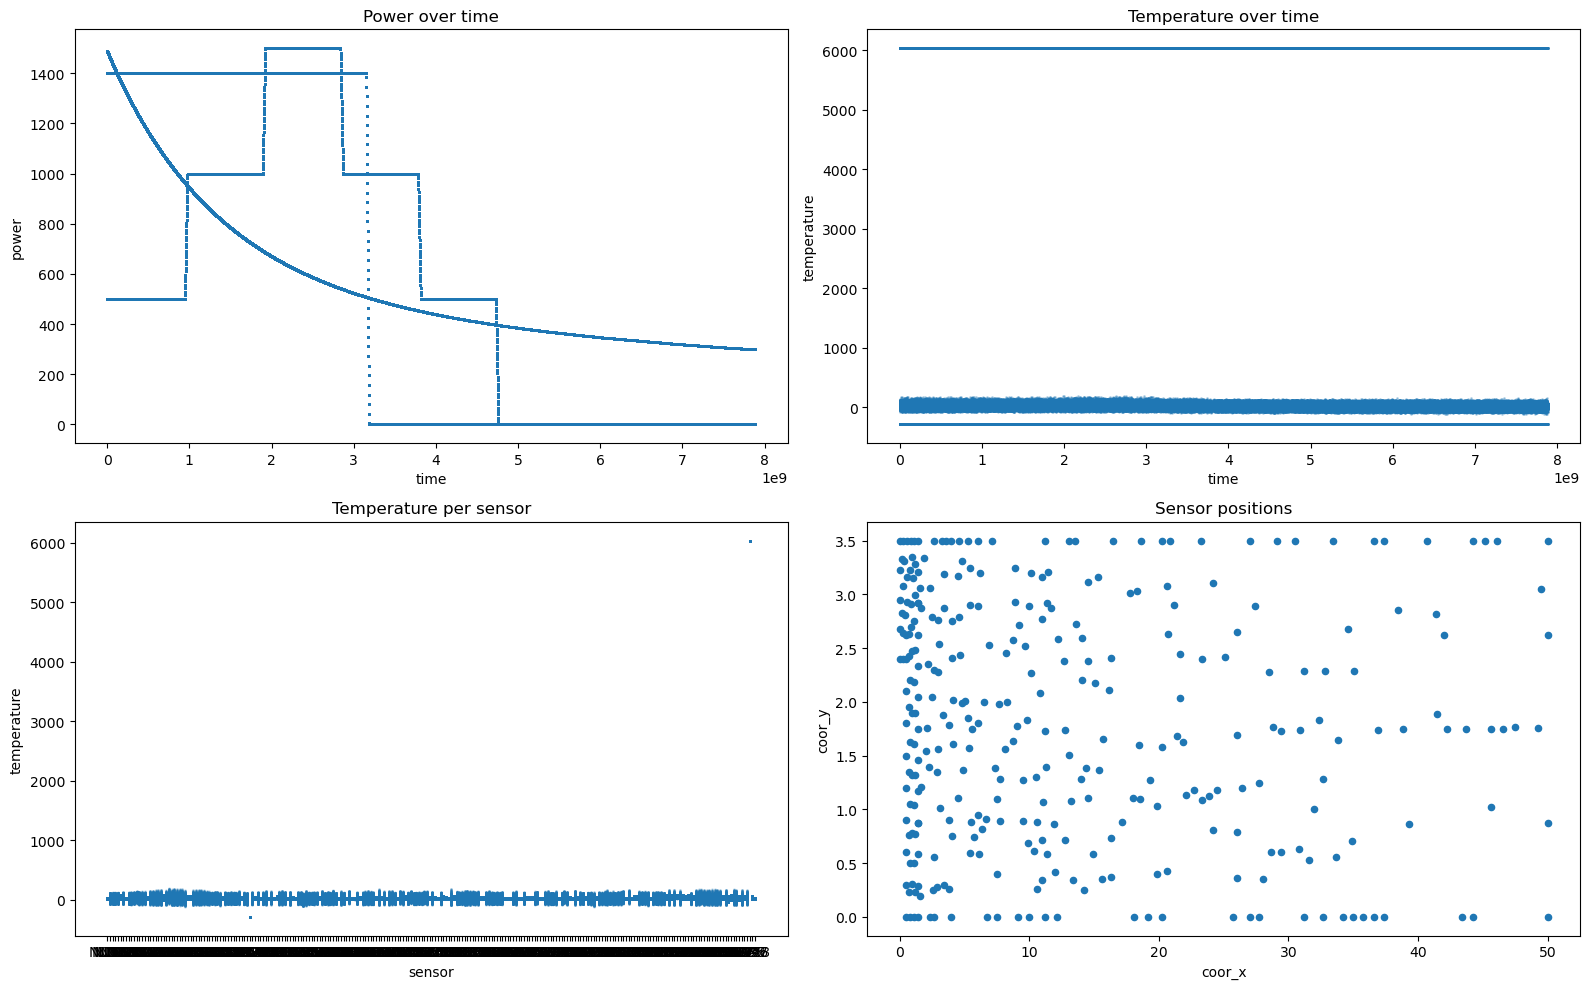

In [205]:
#visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

train.plot(kind='scatter', x='time', y='power', ax=axes[0,0], title='Power over time', s=1)
train.plot(kind='scatter', x='time', y='temperature', alpha=0.3, ax=axes[0,1], title='Temperature over time', s=1)
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15, ax=axes[1,0], title='Temperature per sensor', s=1)
sensors.plot(kind='scatter', x='coor_x', y='coor_y', ax=axes[1,1], title='Sensor positions')

plt.tight_layout()
plt.show()

### Key Observations

<div style="text-align: justify;">
Through the exploratory data analysis, we identified several important characteristics 
of the dataset that will guide our preprocessing steps :

- **Missing values :** 99403 temperature values are missing across multiple sensors 
and will need to be imputed before training.

- **Outlier sensors :** Two sensors (N277 and N927) show clearly aberrant temperature 
values (below -292°C and above 6039°C) and will be removed entirely.

- **3 experimental modes :** The power-time plot reveals 3 distinct heating profiles, 
suggesting the data contains 3 separate experiments that should be treated independently.

- **Sensor positions :** The sensors are not evenly distributed in space, 
which means a simple global average would be biased when imputing missing values.

- **Temperature range :** Most sensors record temperatures between 14°C and 30°C, 
with a few reaching higher values close to the canister.
</div>

# 4. Preprocessing

## 4.1 Missing values

<div style="text-align: justify;">
We use linear interpolation grouped by sensor because the data is ordered 
chronologically. This preserves the temporal evolution of each sensor better 
than a global mean, which would ignore the time structure.
</div>

In [ ]:
#list of the missing values
missing_idx = train[train['temperature'].isna()].index
print(missing_idx)
print(len(missing_idx))

Index([    106,     364,     477,     501,     568,     657,     712,     769,
           833,     870,
       ...
       6626263, 6626302, 6626312, 6626504, 6626575, 6626627, 6626671, 6626726,
       6626890, 6626924],
      dtype='int64', length=99403)
99403


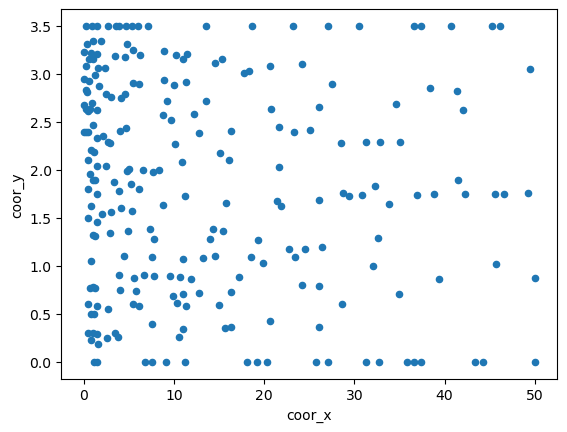

In [207]:
#see where the missing values are --> a bit everywhere
sensors_misval = train.loc[missing_idx, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
plt.show()

In [208]:
#fills the missing temperature by using interpolate because our data is ordered chronologically 
#and taking into account ouly values from the same sensor
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [209]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

## 4.2 Remove outliers

In [210]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [211]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

In [ ]:
#on teste d'enlever encore 2 outliers en plus pour voir si ça améliore les résultats du modèle
for sensor in ['N204', 'N196']:
    train = train[train['sensor'] != sensor]
    sensors = sensors[sensors['sensor'] != sensor]
    
print(f"Capteurs défectueux supprimés !")
print(f"Taille train : {len(train)}")

In [212]:
#control if values are reasonable
print("Min température:", train['temperature'].min())
print("Max température:", train['temperature'].max())
print("Mean température:", train['temperature'].mean())

Min température: -119.05078
Max température: 186.7141
Mean température: 23.145048


<Axes: xlabel='sensor', ylabel='temperature'>

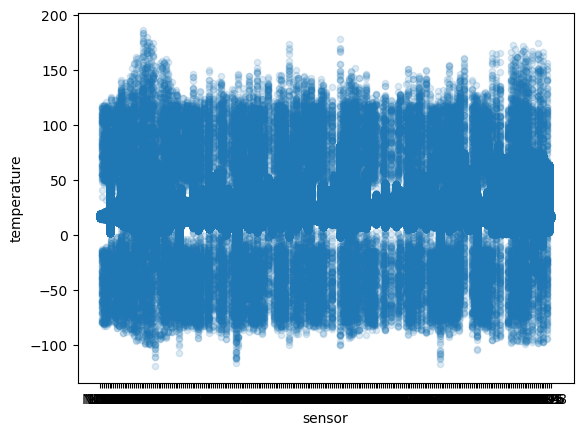

In [ ]:
#Visualization after getting rid of 4 bad sensors
train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

# Filtre global

In [ ]:
# Filtre global sur les températures physiquement impossibles
before = len(train)
train = train[(train['temperature'] >= -30) & (train['temperature'] <= 190)]
after = len(train)
print(f"Lignes supprimées : {before - after} ({(before-after)/before*100:.2f}%)")

## 4.3 Merge coordinates with the training data

In [214]:
#we see there are duplicates in sensors
print(sensors['sensor'].duplicated().sum())  # y a-t-il des doublons ?
print(sensors.shape)
print(sensors['sensor'].nunique())

2
(323, 4)
321


In [215]:
#drop duplicates
sensors_unique = sensors.drop_duplicates(subset='sensor')

In [216]:
# merge the train dataframe with the sensors dataframe to get the coordinates of each sensor
train = train.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
train = train.drop(columns=['coor_z'])

# merge the test dataframe with the sensors dataframe to get the coordinates of each sensor
test = test.merge(sensors_unique[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')
#drop the coor_z column because it is not useful for our model and it is highly correlated with coor_x and coor_y
test = test.drop(columns=['coor_z'])

# control
print(train.columns)

Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y'], dtype='str')


## 4.3 Normalisation

<div style="text-align: justify;">
We normalize time and power using StandardScaler because their scales differ 
greatly (billions vs 0-1500). This ensures that no feature dominates the model 
simply due to its magnitude.
</div>

In [218]:
# Normalisation of time and power
scaler = StandardScaler()
train[['time', 'power']] = scaler.fit_transform(train[['time', 'power']])

# Normalisation of coordinates
scaler_coords = StandardScaler()
train[['coor_x', 'coor_y']] = scaler_coords.fit_transform(
    train[['coor_x', 'coor_y']]
)

# Verification
print(train[['time', 'power', 'coor_x', 'coor_y']].describe())

               time         power        coor_x        coor_y
count  6.572160e+06  6.572160e+06  6.572160e+06  6.572160e+06
mean   7.306779e-17 -8.247803e-17  1.783090e-08 -5.824759e-08
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055347e+00 -9.957756e-01 -1.666897e+00
25%   -8.657853e-01 -1.055347e+00 -8.403574e-01 -8.692871e-01
50%    1.327983e-04 -2.098822e-01 -3.490839e-01  5.826836e-03
75%    8.660130e-01  8.463630e-01  5.941306e-01  8.908014e-01
max    1.731931e+00  1.797218e+00  2.670097e+00  1.513439e+00


In [219]:
# Normalisation of time and power
scaler = StandardScaler()
test[['time', 'power']] = scaler.fit_transform(test[['time', 'power']])

# Normalisation of coordinates
scaler_coords = StandardScaler()
test[['coor_x', 'coor_y']] = scaler_coords.fit_transform(
    test[['coor_x', 'coor_y']]
)

# Verification
print(test[['time', 'power', 'coor_x', 'coor_y']].describe())

               time         power        coor_x        coor_y
count  2.190480e+06  2.190480e+06  2.190480e+06  2.190480e+06
mean  -1.909936e-17  4.691798e-17  4.458212e-08  2.496599e-08
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -1.732045e+00 -1.055280e+00 -1.026388e+00 -1.454405e+00
25%   -8.659751e-01 -1.055280e+00 -8.565745e-01 -8.003416e-01
50%    1.328482e-04 -2.099418e-01 -2.168856e-01 -1.153435e-01
75%    8.662028e-01  8.465250e-01  5.098840e-01  8.950949e-01
max    1.731931e+00  1.797427e+00  2.736567e+00  1.525595e+00


## 4.4 Separation of modes

<div style="text-align: justify;">
The power-time plot reveals 3 distinct experimental modes. Since each sensor has 
27384 timesteps split into 3 equal blocks of 9128, we separate them by dividing 
the dataset into 3 equal parts of 2190720 rows each.
</div>

(2190720, 6) (2190720, 6) (2190720, 6)


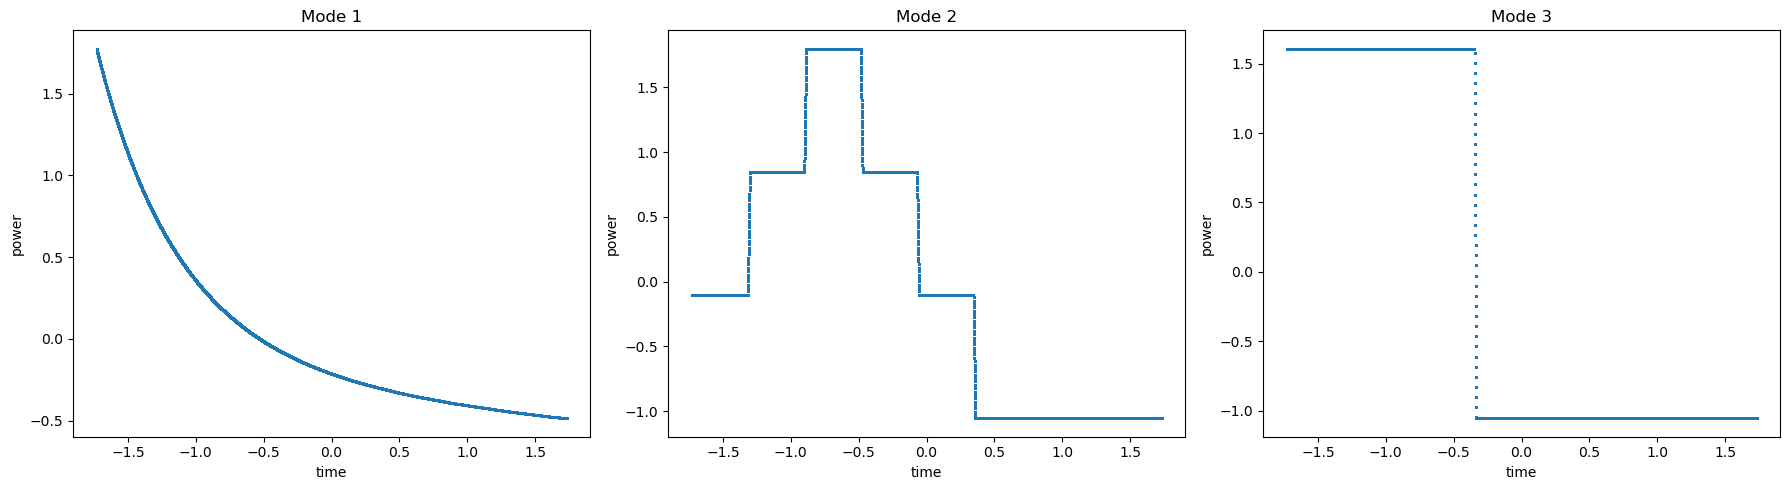

In [220]:
#separate out three modes so that we can try different models for different modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Control
print(mode1.shape, mode2.shape, mode3.shape)

# Visualization of the three modes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

## 4.5 Sensor drift

In [221]:
def remove_outliers(df, threshold=3, column='temperature'):
    mask = np.abs(stats.zscore(df[column])) < threshold
    return df[mask]

In [222]:
random_sensor = mode1['sensor'].sample(1).values[0]
subset = train[train['sensor'] == random_sensor]
print(f"Sensor: {random_sensor}, shape: {subset.shape}")

Sensor: N905, shape: (27384, 6)


<Axes: xlabel='time', ylabel='temperature'>

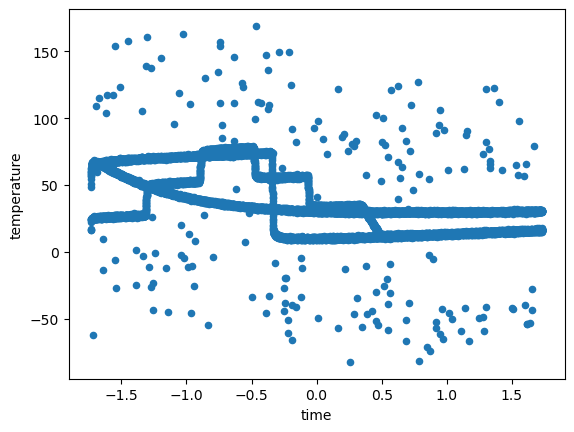

In [223]:
subset.plot(kind='scatter', x='time', y='temperature')

Before: 27384, After: 27285, Removed: 99


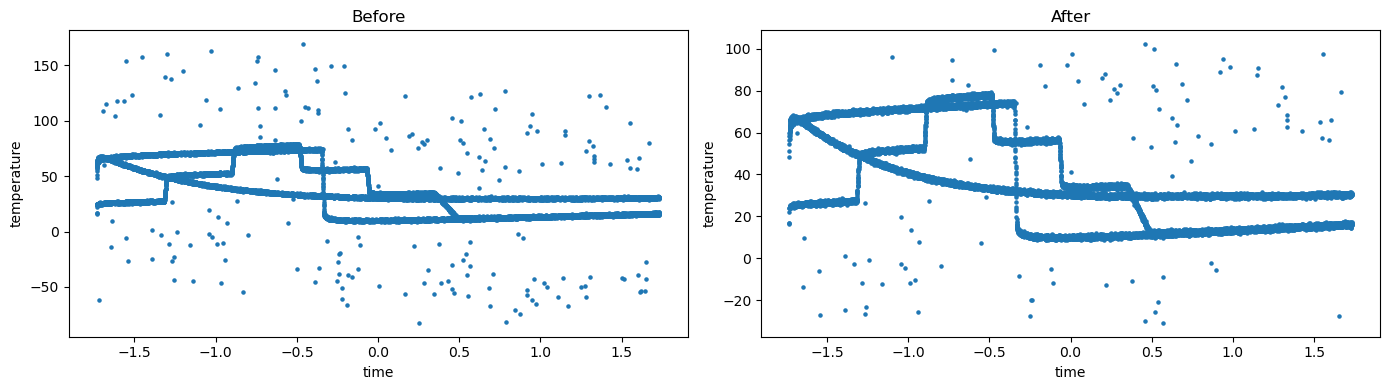

In [224]:
subset_clean = subset[np.abs(stats.zscore(subset['temperature'])) < 3]

print(f"Before: {len(subset)}, After: {len(subset_clean)}, Removed: {len(subset) - len(subset_clean)}")

# Plot to compare
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
subset.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Before', s=5)
subset_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='After', s=5)
plt.tight_layout()
plt.show()

In [225]:
#cleans each modes and each sensors separatly
mode1_clean = (
    mode1.merge(sensors_unique, on='sensor')
    .groupby('sensor', group_keys=False)
    .apply(lambda df: remove_outliers(df))
)

mode2_clean = (
    mode2.merge(sensors_unique, on='sensor')
    .groupby('sensor', group_keys=False)
    .apply(lambda df: remove_outliers(df))
)

mode3_clean = (
    mode3.merge(sensors_unique, on='sensor')
    .groupby('sensor', group_keys=False)
    .apply(lambda df: remove_outliers(df))
)

train_clean = pd.concat([mode1_clean, mode2_clean, mode3_clean], ignore_index=True)
print(f"Total train_clean: {len(train_clean)}")
print(train.shape)

Total train_clean: 6538179
(6572160, 6)


In [226]:
BLOCK = len(train_clean) // 3

mode1_clean = train_clean.iloc[0       : BLOCK].copy()
mode2_clean = train_clean.iloc[BLOCK   : 2*BLOCK].copy()
mode3_clean = train_clean.iloc[2*BLOCK :].copy()

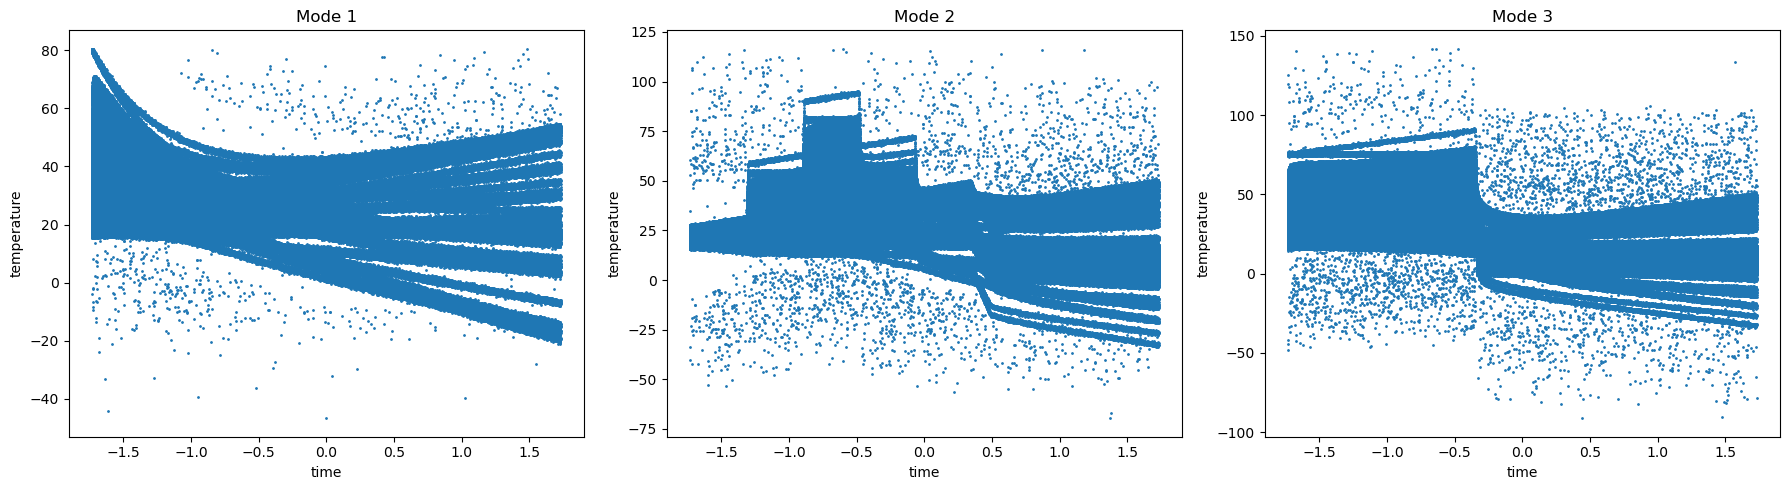

In [227]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3_clean.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

# 5. Model Training

blablabla c'est ici qu'on teste plusieurs modèles, voilàààààà

## 5.1 Linear regression

résultat sur le learderboard : 7.87198 sans le drift, le filtre général et l'enlèvement des 2 outliers supplémentaires

In [19]:
from sklearn.model_selection import train_test_split

# Définir les features et la target manuellement
features = ['time', 'power', 'coor_x', 'coor_y']
target = 'temperature'

X = train[features].values
y = train[target].values

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (5257728, 4)
X_test shape: (1314432, 4)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Créer et entraîner le modèle
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prédictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# Evaluer avec RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"RMSE Train: {rmse_train:.4f}")
print(f"RMSE Test:  {rmse_test:.4f}")

RMSE Train: 11.6831
RMSE Test:  11.6995


In [21]:
# 1. D'abord supprimer les doublons
sensors_clean = sensors.drop_duplicates(subset='sensor')

# 2. Ensuite merger
test = test.merge(sensors_clean[['sensor', 'coor_x', 'coor_y', 'coor_z']], on='sensor', how='left')

# Vérification cruciale
print(f"Nombre de lignes test après merge : {len(test)}")
# Ce nombre doit être 2190480

Nombre de lignes test après merge : 2190480


In [22]:
# Normalisation de test avec les mêmes scalers que le train
test[['time', 'power']] = scaler.transform(test[['time', 'power']])
test[['coor_x', 'coor_y', 'coor_z']] = scaler_coords.transform(test[['coor_x', 'coor_y', 'coor_z']])

print("test après normalisation:")
print(test[['time', 'power', 'coor_x', 'coor_y']].describe())

test après normalisation:
               time         power        coor_x        coor_y
count  2.190480e+06  2.190480e+06  2.190480e+06  2.190480e+06
mean   1.897716e-04 -1.196773e-04  4.132370e-03 -1.147173e-01
std    9.998906e-01  9.999502e-01  9.742007e-01  1.067227e+00
min   -1.731666e+00 -1.055347e+00 -9.957756e-01 -1.666897e+00
25%   -8.656904e-01 -1.055347e+00 -8.303429e-01 -9.688633e-01
50%    3.226052e-04 -2.100510e-01 -2.071577e-01 -2.378149e-01
75%    8.662977e-01  8.463630e-01  5.008615e-01  8.405520e-01
max    1.731931e+00  1.797218e+00  2.670097e+00  1.513439e+00


In [31]:
# Prédictions sur le vrai test set
#X_kaggle = test[['time', 'power', 'coor_x', 'coor_y']].values
#y_pred = lr_model.predict(X_kaggle)

#print(f"Prédictions générées : {len(y_pred)} lignes")
#print(y_pred[:10])
#print(y_pred.min(), y_pred.max())

# 5.2 NN

score sur le leaderbord : 5.74

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

# Convertir les données en tenseurs PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Dataset et DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)

# Définition du MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialiser le modèle
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


Device utilisé : cpu


In [30]:
# Entraînement
N_EPOCHS = 20
for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_hat = model(X_batch)
        loss = criterion(y_hat, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # RMSE sur le test set
    model.eval()
    with torch.no_grad():
        y_hat_test = model(X_test_tensor)
        rmse = torch.sqrt(criterion(y_hat_test, y_test_tensor)).item()
    
    print(f"Epoch {epoch+1}/{N_EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | RMSE Test: {rmse:.4f}")

Epoch 1/20 | Loss: 89.3140 | RMSE Test: 7.7545
Epoch 2/20 | Loss: 57.7114 | RMSE Test: 7.5230
Epoch 3/20 | Loss: 54.3776 | RMSE Test: 7.3051
Epoch 4/20 | Loss: 51.3345 | RMSE Test: 7.0889
Epoch 5/20 | Loss: 48.5382 | RMSE Test: 6.9252
Epoch 6/20 | Loss: 46.5159 | RMSE Test: 6.7757
Epoch 7/20 | Loss: 44.8920 | RMSE Test: 6.7542
Epoch 8/20 | Loss: 43.3890 | RMSE Test: 6.5601
Epoch 9/20 | Loss: 42.0108 | RMSE Test: 6.4624
Epoch 10/20 | Loss: 40.8776 | RMSE Test: 6.3546
Epoch 11/20 | Loss: 39.8935 | RMSE Test: 6.2885
Epoch 12/20 | Loss: 38.9431 | RMSE Test: 6.2242
Epoch 13/20 | Loss: 37.9906 | RMSE Test: 6.1616
Epoch 14/20 | Loss: 37.2715 | RMSE Test: 6.0953
Epoch 15/20 | Loss: 36.6868 | RMSE Test: 6.1454
Epoch 16/20 | Loss: 36.1497 | RMSE Test: 6.0160
Epoch 17/20 | Loss: 35.7644 | RMSE Test: 6.0386
Epoch 18/20 | Loss: 35.3599 | RMSE Test: 5.9722
Epoch 19/20 | Loss: 35.0027 | RMSE Test: 5.9366
Epoch 20/20 | Loss: 34.6358 | RMSE Test: 5.9317


In [32]:
# Prédictions sur le vrai test set
X_kaggle = test[['time', 'power', 'coor_x', 'coor_y']].values

# Prédictions avec le MLP
model.eval()
with torch.no_grad():
    X_kaggle_tensor = torch.tensor(X_kaggle, dtype=torch.float32).to(device)
    y_pred = model(X_kaggle_tensor).cpu().numpy().flatten()

print(f"Prédictions générées : {len(y_pred)} lignes")
print(y_pred[:10])
print(y_pred.min(), y_pred.max())

Prédictions générées : 2190480 lignes
[17.838444 17.838467 17.838512 17.838543 17.838593 17.838615 17.838661
 17.83868  17.83871  17.838757]
-34.806023 81.8426


## 5.3 KNN

In [165]:
train_coor_temp = train_clean.drop(columns=['time', 'power', 'coor_x_y', 'coor_y_y', 'coor_z'])

test_unlab = test.drop(columns=['sensor', 'time', 'power']).to_numpy()

print(train_coor_temp.head())
print(test_unlab)

   temperature  coor_x_x  coor_y_x
0    17.514429  2.386466  1.513439
1    17.820795  2.386466  1.513439
2    17.573187  2.386466  1.513439
3    16.513235  2.386466  1.513439
4    16.303427  2.386466  1.513439
[[2.305995   1.5255954 ]
 [2.305995   1.5255954 ]
 [2.305995   1.5255954 ]
 ...
 [2.7365668  0.78059524]
 [2.7365668  0.78059524]
 [2.7365668  0.78059524]]


In [163]:
#Transforms data into numpy arrays and splits it into a train, val and test set
def preprocess_data(
    df: pd.DataFrame,
    label: str,
    train_size: float = 0.6,
    val_size: float = 0.2,
    seed: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    List[str],
]:
    df = df.sample(frac=1, random_state=seed)

    train, val, test = (
        df[: int(len(df) * train_size)],
        df[int(len(df) * train_size) : int(len(df) * (train_size + val_size))],
        df[int(len(df) * (train_size + val_size)) :],
    )

    X_train = train.drop(columns=label).to_numpy()
    X_val = val.drop(columns=label).to_numpy()
    X_test = test.drop(columns=label).to_numpy()

    y_train = train[label].to_numpy()
    y_val = val[label].to_numpy()
    y_test = test[label].to_numpy()

    return X_train, y_train, X_val, y_val, X_test, y_test

In [161]:
def knn_predict_mode(mode, sensors_unique, k=21, seed=42):
    # Merge with sensors coordinates

    merged = mode.merge(sensors_unique, on='sensor')
    merged = merged.drop(columns=['sensor', 'power'])

    # Preprocess
    X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(
        merged, label='temperature', seed=seed
    )

    # Train
    tree = KDTree(X_train)

    # Evaluate on val and test
    _, idx_val = tree.query(X_val, k=k, workers=-1)
    y_val_pred = np.mean(y_train[idx_val], axis=1)
    rmse_val = np.sqrt(np.mean((y_val - y_val_pred) ** 2))

    _, idx_test = tree.query(X_test, k=k, workers=-1)
    y_test_pred = np.mean(y_train[idx_test], axis=1)
    rmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2))

    print(f"RMSE val: {rmse_val:.4f} | RMSE test: {rmse_test:.4f}")

    return y_test_pred

In [170]:
y_pred_mode1 = knn_predict_mode(mode1, sensors_unique)
y_pred_mode2 = knn_predict_mode(mode2, sensors_unique)
y_pred_mode3 = knn_predict_mode(mode3, sensors_unique)

RMSE val: 5.4568 | RMSE test: 5.5086
RMSE val: 5.2917 | RMSE test: 5.4567
RMSE val: 5.5151 | RMSE test: 5.4092


In [ ]:
def knn_predict_unlabeled(mode, test, sensors_unique, k=21, seed=42):
    # Prepare train
    merged_train = mode.merge(sensors_unique, on='sensor')
    merged_train = merged_train.drop(columns=['sensor', 'power'])

    X_train = merged_train.drop(columns=['temperature']).to_numpy()
    y_train = merged_train['temperature'].to_numpy()

    # Prepare unlabeled test
    merged_test = test.merge(sensors_unique, on='sensor')
    X_test = merged_test.drop(columns=['sensor', 'power']).to_numpy()

    # Predict
    tree = KDTree(X_train)
    _, indices = tree.query(X_test, k=k, workers=-1)
    y_pred = np.mean(y_train[indices], axis=1)

    return y_pred

In [234]:
y_pred = knn_predict_unlabeled(train, test, sensors_unique)

# SETUP FOR MODELS TRAINING (LEADERBOARD)

In [236]:
submission = pd.DataFrame({
   "Id": np.arange(len(test), dtype=int),
   "temperature": y_pred,
})
assert list(submission.columns) == ["Id", "temperature"]
assert len(submission) == len(test)
assert (submission["Id"].to_numpy() == np.arange(len(test))).all()
assert np.isfinite(submission["temperature"]).all()
assert submission.isna().sum().sum() == 0
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


Saved submission.csv
